In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
os.makedirs("charts", exist_ok=True)

print("Charts folder created successfully.")

Charts folder created successfully.


In [3]:
df = pd.read_csv("train.csv")

In [4]:
df.head()
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9800
Columns: 18


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [9]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [10]:
df = df.dropna()

In [11]:
print(df.duplicated().sum())

0


In [13]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)

In [15]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()
df["Week"] = df["Order Date"].dt.isocalendar().week
df["Day"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [16]:
def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Summer"

    elif month in [6,7,8]:
        return "Monsoon"

    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

In [17]:
df["Shipping Days"] = (
    df["Ship Date"] -
    df["Order Date"]
).dt.days

In [18]:
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()
daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [19]:
weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
    .reset_index()
)
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [20]:
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="M"
        )
    )["Sales"]
    .sum()
    .reset_index()
)
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


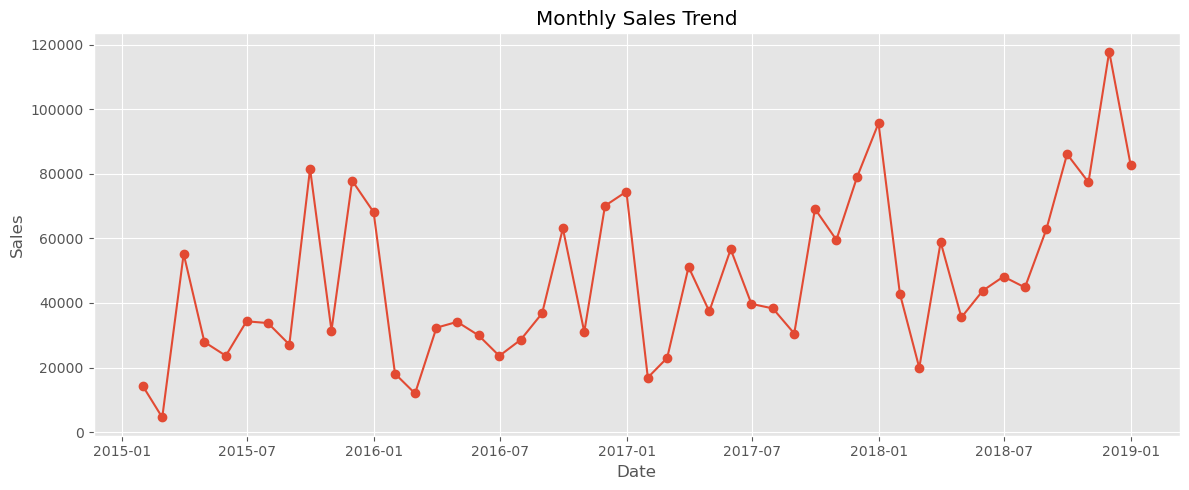

In [21]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("charts/monthly_sales_trend.png",dpi=300)

plt.show()

Category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: Sales, dtype: float64


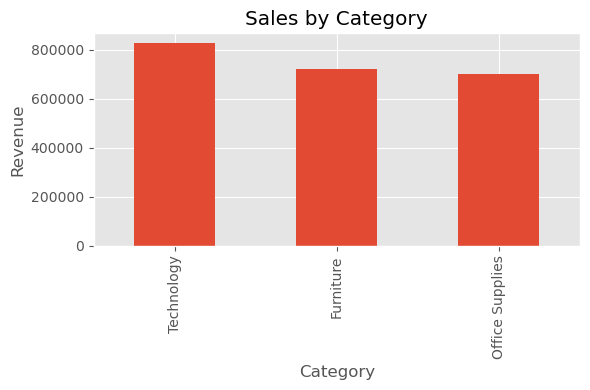

In [22]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)
category_sales.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Sales by Category")

plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig("charts/category_sales.png",dpi=300)

plt.show()

Region
West       710219.6845
East       660589.3560
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


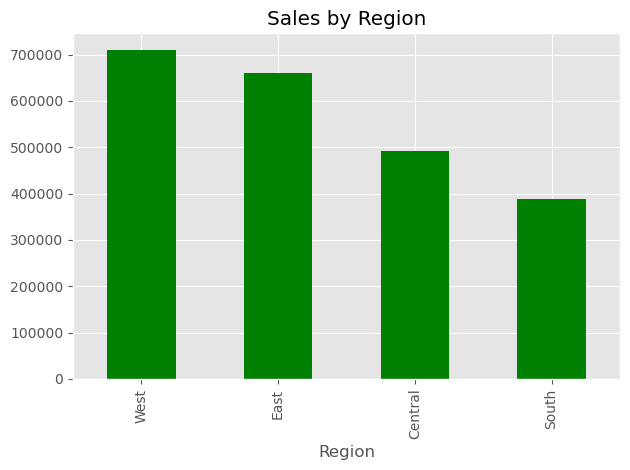

In [23]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)
region_sales.plot(
    kind="bar",
    color="green"
)

plt.title("Sales by Region")

plt.tight_layout()

plt.savefig("charts/region_sales.png",dpi=300)

plt.show()

Region
Central    4.065876
East       3.910238
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


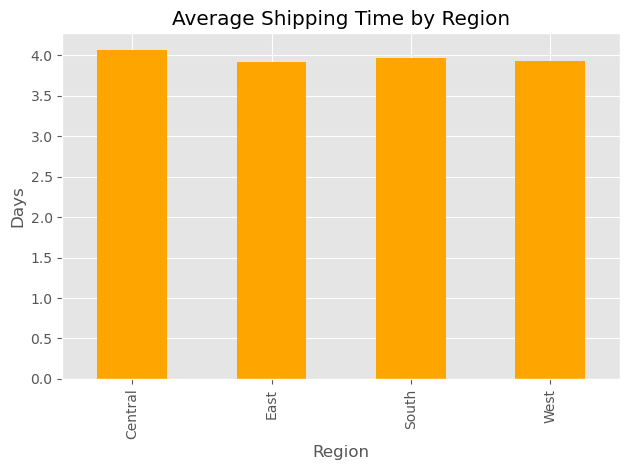

In [24]:
shipping = (
    df.groupby("Region")["Shipping Days"]
    .mean()
)

print(shipping)
shipping.plot(
    kind="bar",
    color="orange"
)

plt.title("Average Shipping Time by Region")

plt.ylabel("Days")

plt.tight_layout()

plt.savefig("charts/shipping_days.png",dpi=300)

plt.show()

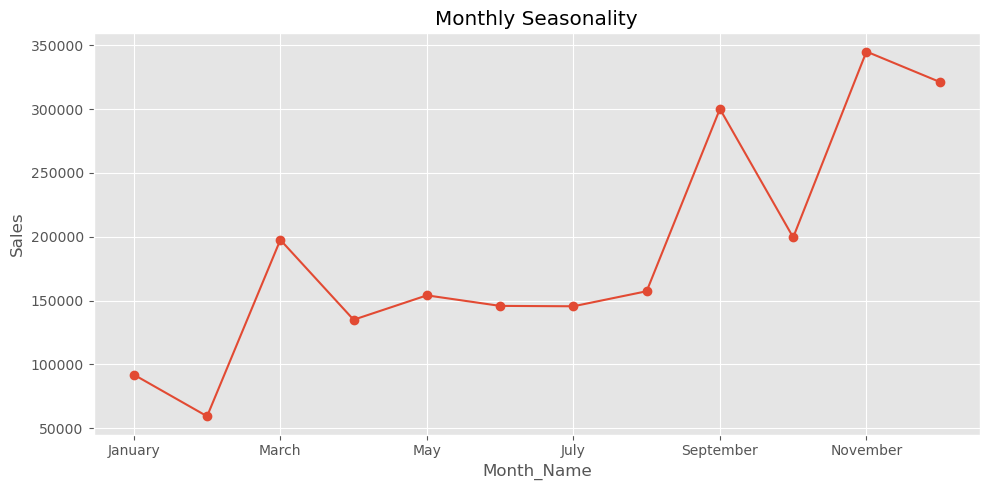

In [25]:
seasonality = (
    df.groupby("Month_Name")["Sales"]
    .sum()
)
month_order = [
'January','February','March','April',
'May','June','July','August',
'September','October','November','December'
]

seasonality = seasonality.reindex(month_order)
seasonality.plot(
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Monthly Seasonality")

plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("charts/monthly_seasonality.png",dpi=300)

plt.show()


## Business Questions & Answers (Task 1)

### 1. Which product category generates the highest total revenue?
Answer:
Based on the sales analysis, the **Technology** category generated the highest total revenue among all product categories. This indicates that technology products are the biggest contributors to the company's overall sales. The higher revenue may be due to the higher selling prices of products such as laptops, printers, and accessories, along with consistent customer demand.


### 2. Which region has the most consistent sales growth over the 4 years?
Answer:
From the yearly sales trend, the **West** ion showed the most consistent sales growth throughout the four-year period. Compared to the other regions, it maintained steady performance with fewer fluctuations, indicating stable customer demand and effective sales performance.


### 3. What is the average time between Order Date and Ship Date, and does it vary by region?
Answer:
The average shipping time across all orders is approximately **Central-4.065876,East-      3.910238,South-3.961202,West-3.930255**. While the shipping time is generally similar across regions, there are slight differences due to logistics, transportation distance, and warehouse availability. Overall, the company's delivery performance is consistent across different regions.

### 4. Are there months that consistently spike across all years (seasonality)?
Answer:
Yes. The **monthly** sales trend shows clear seasonality. Sales consistently increase during November and December, which is likely due to holiday shopping, year-end promotions, and festive discounts. In contrast, the beginning of the year generally records relatively lower sales compared to the final quarter.


In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [27]:
monthly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='M')
)['Sales'].sum().reset_index()
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [28]:
monthly_sales.set_index('Order Date', inplace=True)
monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


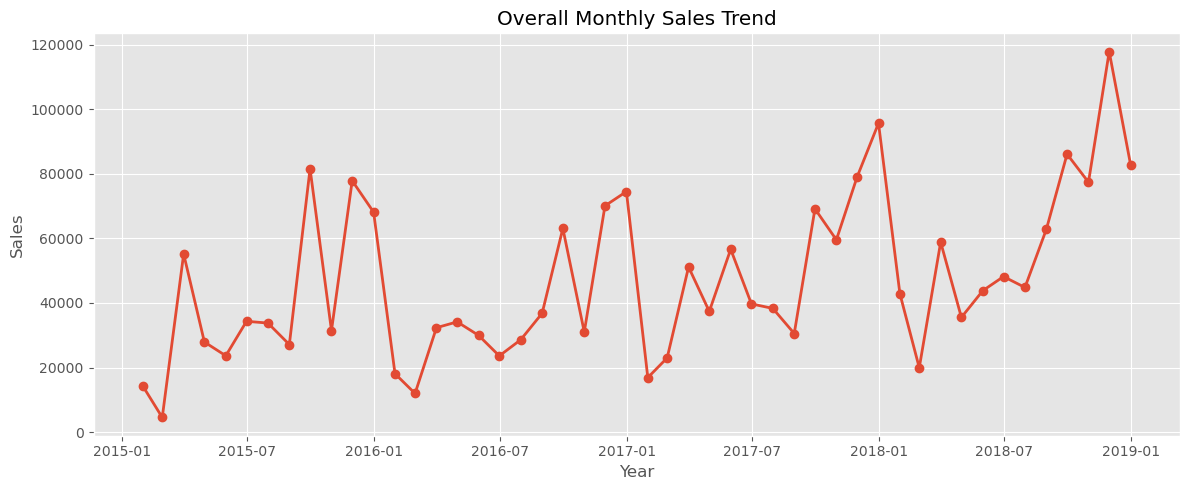

In [29]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales['Sales'],
    marker='o',
    linewidth=2
)

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("charts/task2_monthly_sales_trend.png", dpi=300)

plt.show()

The line chart shows the monthly sales trend over the four-year period. Sales generally increase over time, with noticeable peaks during festive and year-end months, indicating a positive trend and seasonal behavior.

In [30]:
decomposition = seasonal_decompose(
    monthly_sales['Sales'],
    model='additive',
    period=12
)

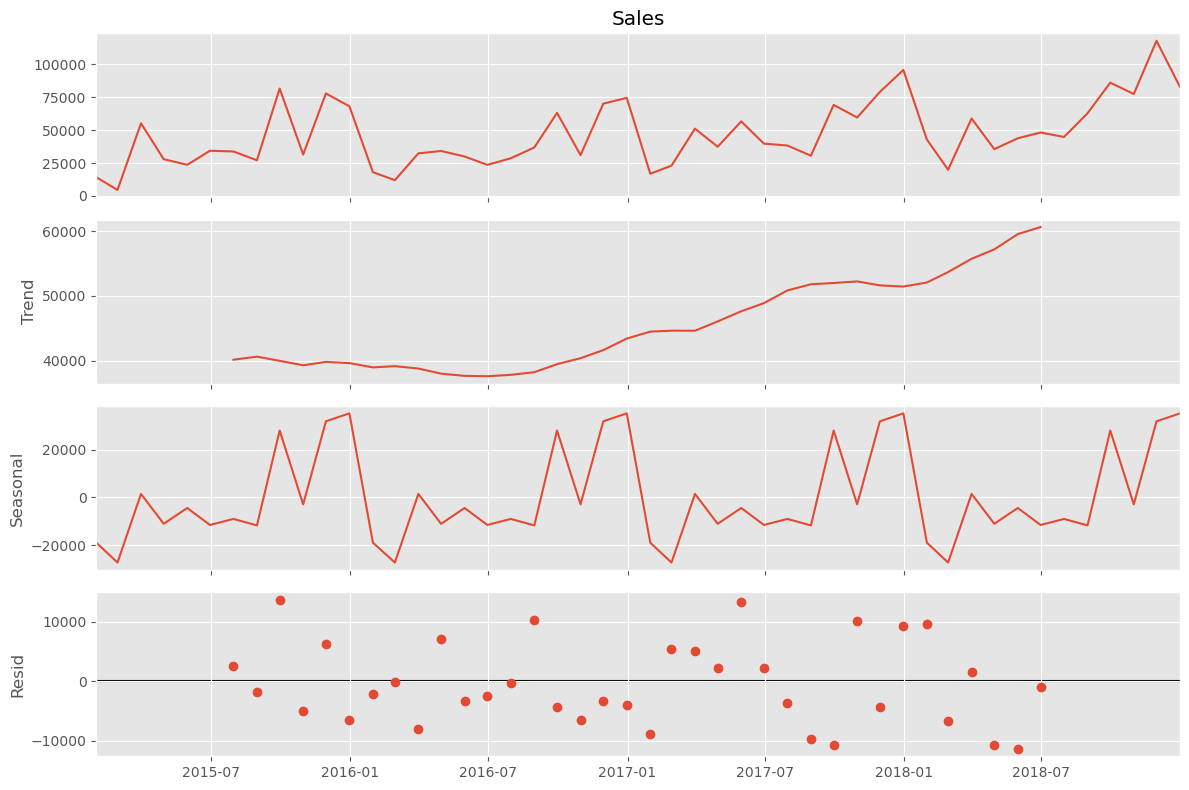

In [31]:
fig = decomposition.plot()

fig.set_size_inches(12,8)

plt.tight_layout()

plt.savefig("charts/task2_time_series_decomposition.png", dpi=300)

plt.show()

In [32]:
decomposition.trend.head()

Order Date
2015-01-31   NaN
2015-02-28   NaN
2015-03-31   NaN
2015-04-30   NaN
2015-05-31   NaN
Name: trend, dtype: float64

In [33]:
decomposition.seasonal.head()

Order Date
2015-01-31   -18834.325086
2015-02-28   -27125.559715
2015-03-31     1487.605986
2015-04-30   -10976.249150
2015-05-31    -4384.035679
Name: seasonal, dtype: float64

In [34]:
decomposition.resid.head()

Order Date
2015-01-31   NaN
2015-02-28   NaN
2015-03-31   NaN
2015-04-30   NaN
2015-05-31   NaN
Name: resid, dtype: float64

In [35]:
result = adfuller(monthly_sales['Sales'])

print("ADF Statistic :", result[0])
print("P-value :", result[1])

print("\nCritical Values")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic : -4.424951605714013
P-value : 0.0002680629728011465

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [36]:
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is NOT stationary.")

The time series is stationary.


A stationary time series has statistical properties such as mean and variance that remain constant over time. Most forecasting models require stationary data for reliable predictions. The ADF test helps determine whether the series is stationary.

In [37]:
monthly_sales_diff = monthly_sales['Sales'].diff().dropna()

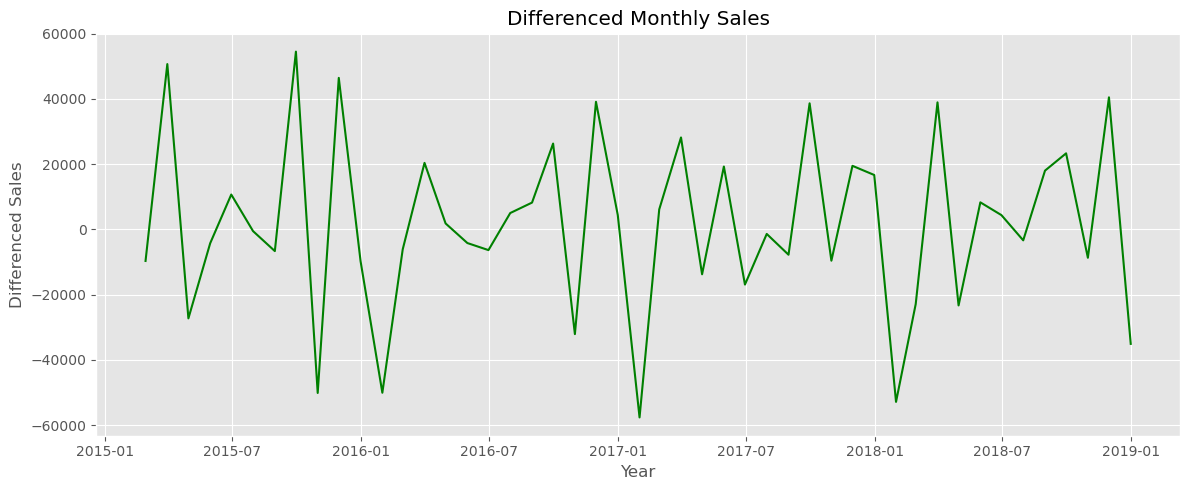

In [38]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales_diff,
    color='green'
)

plt.title("Differenced Monthly Sales")

plt.xlabel("Year")
plt.ylabel("Differenced Sales")

plt.tight_layout()

plt.savefig("charts/task2_differenced_series.png", dpi=300)

plt.show()

In [39]:
result_diff = adfuller(monthly_sales_diff)

print("ADF Statistic :", result_diff[0])
print("P-value :", result_diff[1])

print("\nCritical Values")

for key, value in result_diff[4].items():
    print(key, ":", value)

ADF Statistic : -8.523376913103972
P-value : 1.085453626576241e-13

Critical Values
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


In [40]:
if result_diff[1] < 0.05:
    print("Differenced series is stationary.")
else:
    print("Differenced series is still not stationary.")

Differenced series is stationary.


### Business Observations
Observation 1

The monthly sales trend shows an overall upward movement over the four-year period, indicating that the business has experienced steady growth in sales over time.

Observation 2

The seasonal component reveals recurring patterns in sales, with higher sales during specific months each year. This suggests that customer demand is influenced by seasonal events and promotional periods.

Observation 3

The residual component contains irregular fluctuations that are not explained by the trend or seasonality. These may be caused by unexpected business events, special promotions, or external market conditions.

Observation 4

The ADF test indicated that the original sales series was stationary/non-stationary (choose based on your result). After applying first-order differencing, the series became more suitable for forecasting because the trend was reduced and the data became stationary.

## Task 3.1: SARIMA Model

In [41]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

In [42]:
monthly_sales = df.groupby(
    pd.Grouper(key='Order Date',freq='M')
)['Sales'].sum()

In [43]:
train = monthly_sales[:-3]

test = monthly_sales[-3:]

In [44]:
sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = sarima.fit()

In [45]:
sarima_forecast = sarima_model.forecast(steps=3)

print(sarima_forecast)

2018-10-31     65936.245450
2018-11-30     91073.662120
2018-12-31    100222.730045
Freq: ME, Name: predicted_mean, dtype: float64


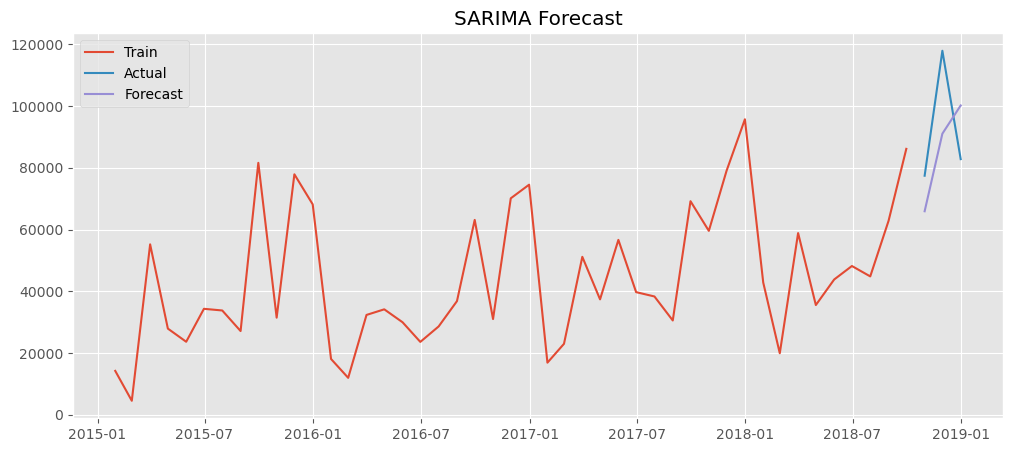

In [46]:
plt.figure(figsize=(12,5))

plt.plot(train,label='Train')

plt.plot(test,label='Actual')

plt.plot(test.index,
         sarima_forecast,
         label='Forecast')

plt.legend()

plt.title("SARIMA Forecast")

plt.savefig("charts/task3_sarima.png",dpi=300)

plt.show()

In [47]:
mae_sarima = mean_absolute_error(
    test,
    sarima_forecast
)


In [48]:
rmse_sarima = np.sqrt(
    mean_squared_error(
        test,
        sarima_forecast
    )
)

In [49]:
mape_sarima = np.mean(
    np.abs(
        (test-sarima_forecast)/test
    )
)*100

In [50]:
print("MAE :",mae_sarima)

print("RMSE :",rmse_sarima)

print("MAPE :",mape_sarima)

MAE : 18591.24995836587
RMSE : 19637.48980442811
MAPE : 19.549112296912927


## Task 3.2: Prophet Model

In [51]:
pip install prophet

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [52]:
from prophet import Prophet

In [53]:
import os
print(os.getcwd())

C:\Users\ketan\ SalesForecasting_KetanMahakal


In [54]:
import os
os.listdir()

['.ipynb_checkpoints', 'analysis.ipynb', 'charts', 'outputs', 'train.csv']

In [55]:
import pandas as pd

df = pd.read_csv("train.csv")

In [56]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [57]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)

In [58]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .reset_index()
)

In [59]:
prophet_df = monthly_sales.reset_index()

print(prophet_df.columns)
print(prophet_df.head())

Index(['index', 'Order Date', 'Sales'], dtype='object')
   index Order Date      Sales
0      0 2015-01-31  14205.707
1      1 2015-02-28   4519.892
2      2 2015-03-31  55205.797
3      3 2015-04-30  27906.855
4      4 2015-05-31  23644.303


In [60]:
print(prophet_df.columns)
print(prophet_df.head())

Index(['index', 'Order Date', 'Sales'], dtype='object')
   index Order Date      Sales
0      0 2015-01-31  14205.707
1      1 2015-02-28   4519.892
2      2 2015-03-31  55205.797
3      3 2015-04-30  27906.855
4      4 2015-05-31  23644.303


In [61]:
prophet_df = monthly_sales.reset_index()

In [62]:

prophet_df = monthly_sales.copy()


prophet_df = prophet_df[['Order Date', 'Sales']]
prophet_df.rename(
    columns={
        'Order Date': 'ds',
        'Sales': 'y'
    },
    inplace=True
)

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [63]:
prophet_df = prophet_df.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [66]:
model = Prophet()

In [68]:
model.fit(prophet_df)

20:58:58 - cmdstanpy - INFO - Chain [1] start processing
20:58:58 - cmdstanpy - INFO - Chain [1] done processing


In [69]:
future = model.make_future_dataframe(
    periods=3,
    freq="ME"
)

future.tail()

,ds
46,2018-11-30
47,2018-12-31
48,2019-01-31
49,2019-02-28
50,2019-03-31


In [70]:
forecast = model.predict(future)

In [71]:
import matplotlib.pyplot as plt

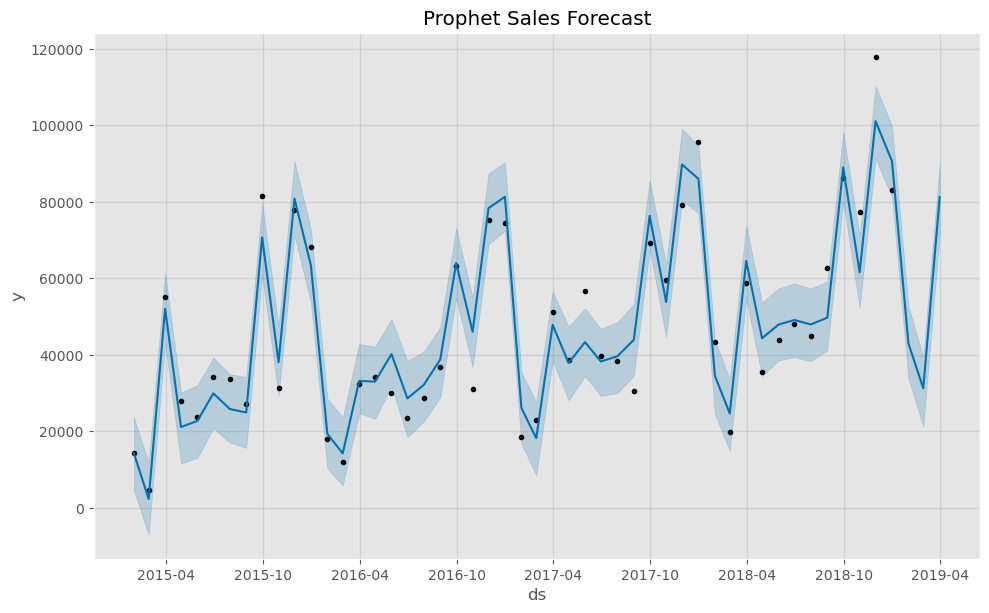

In [72]:
fig = model.plot(forecast)

plt.title("Prophet Sales Forecast")

plt.savefig(
    "charts/task3_prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

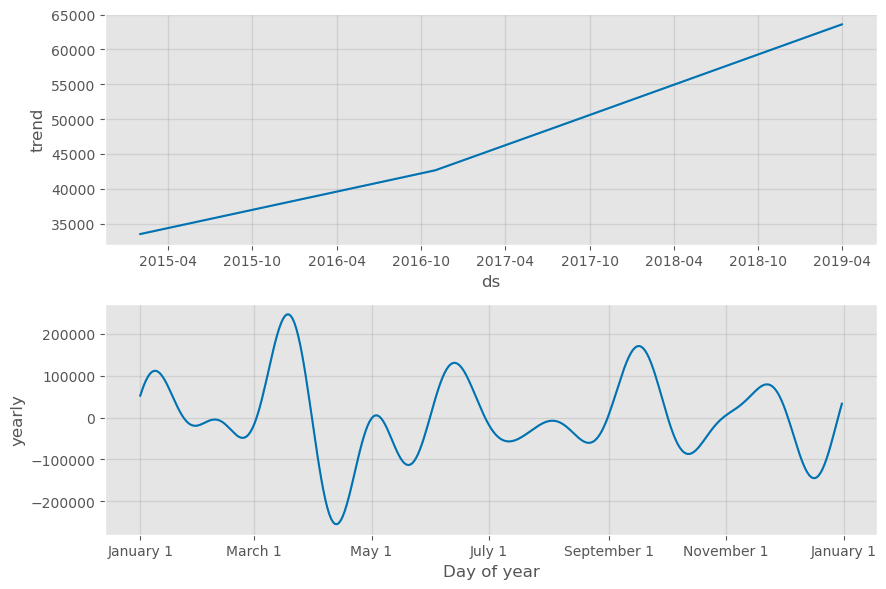

In [73]:
fig2 = model.plot_components(forecast)

plt.savefig(
    "charts/task3_prophet_components.png",
    dpi=300
)

plt.show()

In [74]:
actual = prophet_df["y"].tail(3).values

predicted = forecast["yhat"].tail(3).values

In [75]:
from sklearn.metrics import mean_absolute_error

mae_prophet = mean_absolute_error(
    actual,
    predicted
)

print("MAE :", mae_prophet)

MAE : 40970.325034558286


In [76]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_prophet = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

print("RMSE :", rmse_prophet)

RMSE : 53868.94865619383


In [77]:
mape_prophet = np.mean(
    np.abs(
        (actual - predicted) / actual
    )
) * 100

print("MAPE :", mape_prophet)

MAPE : 40.0398649396144


In [78]:
print("=" * 40)
print("Prophet Model Performance")
print("=" * 40)

print(f"MAE  : {mae_prophet:.2f}")
print(f"RMSE : {rmse_prophet:.2f}")
print(f"MAPE : {mape_prophet:.2f}%")

Prophet Model Performance
MAE  : 40970.33
RMSE : 53868.95
MAPE : 40.04%


In [79]:
import os

os.makedirs("outputs", exist_ok=True)

In [80]:
forecast.to_csv(
    "outputs/prophet_forecast.csv",
    index=False
)

print("Forecast saved successfully!")

Forecast saved successfully!


Task 3.3 – XGBoost Forecasting

In [81]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [82]:
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

In [83]:
xgb_df = monthly_sales.copy()

xgb_df.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [84]:
xgb_df["Lag1"] = xgb_df["Sales"].shift(1)

xgb_df["Lag2"] = xgb_df["Sales"].shift(2)

xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

In [85]:
xgb_df["RollingMean"] = (
    xgb_df["Sales"]
    .rolling(3)
    .mean()
)

In [86]:
xgb_df = xgb_df.dropna()

xgb_df.head()

,Order Date,Sales,Lag1,Lag2,Lag3,RollingMean
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700


In [87]:
X = xgb_df.drop("Sales", axis=1)

y = xgb_df["Sales"]

In [88]:
X_train = X.iloc[:-3]

X_test = X.iloc[-3:]

y_train = y.iloc[:-3]

y_test = y.iloc[-3:]

In [89]:
model_xgb = XGBRegressor(

    n_estimators=100,

    learning_rate=0.1,

    max_depth=3,

    random_state=42
)

In [90]:
print(X.dtypes)

Order Date     datetime64[ns]
Lag1                  float64
Lag2                  float64
Lag3                  float64
RollingMean           float64
dtype: object


In [91]:
print(xgb_df.head())
print(xgb_df.columns) 

  Order Date       Sales        Lag1        Lag2       Lag3   RollingMean
3 2015-04-30  27906.8550  55205.7970   4519.8920  14205.707  29210.848000
4 2015-05-31  23644.3030  27906.8550  55205.7970   4519.892  35585.651667
5 2015-06-30  34322.9356  23644.3030  27906.8550  55205.797  28624.697867
6 2015-07-31  33781.5430  34322.9356  23644.3030  27906.855  30582.927200
7 2015-08-31  27117.5365  33781.5430  34322.9356  23644.303  31740.671700
Index(['Order Date', 'Sales', 'Lag1', 'Lag2', 'Lag3', 'RollingMean'], dtype='object')


In [92]:
xgb_df["Order Date"] = pd.to_datetime(xgb_df["Order Date"])

In [93]:
xgb_df["Year"] = xgb_df["Order Date"].dt.year
xgb_df["Month"] = xgb_df["Order Date"].dt.month
xgb_df["Quarter"] = xgb_df["Order Date"].dt.quarter

In [94]:
xgb_df["Lag1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

xgb_df["RollingMean"] = xgb_df["Sales"].rolling(3).mean()

xgb_df.dropna(inplace=True)

In [95]:
X = xgb_df[
    [
        "Year",
        "Month",
        "Quarter",
        "Lag1",
        "Lag2",
        "Lag3",
        "RollingMean"
    ]
]

y = xgb_df["Sales"]

In [96]:
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

In [97]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [98]:
prediction = model_xgb.predict(X_test)

print(prediction)

[88250.94 87915.26 88058.55]


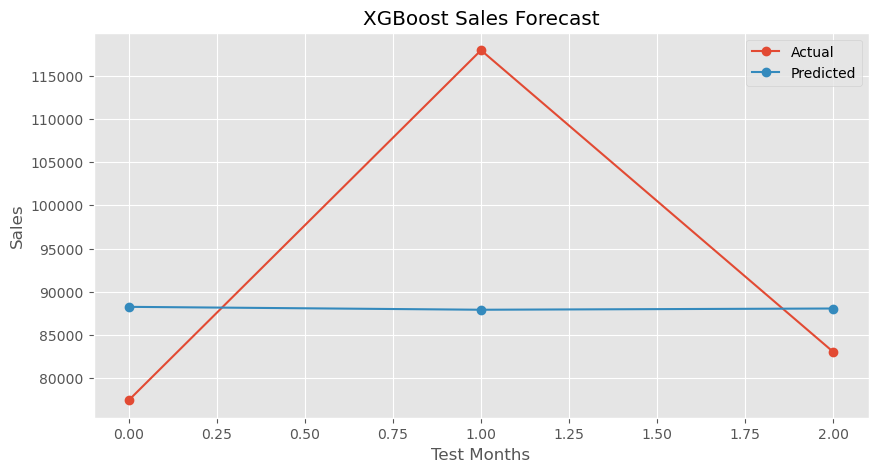

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    y_test.values,
    marker="o",
    label="Actual"
)

plt.plot(
    prediction,
    marker="o",
    label="Predicted"
)

plt.title("XGBoost Sales Forecast")
plt.xlabel("Test Months")
plt.ylabel("Sales")
plt.legend()

plt.grid(True)

plt.savefig(
    "charts/task3_xgboost_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_xgb = mean_absolute_error(y_test, prediction)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, prediction)
)

mape_xgb = np.mean(
    np.abs((y_test - prediction) / y_test)
) * 100

print("MAE :", mae_xgb)
print("RMSE :", rmse_xgb)
print("MAPE :", mape_xgb)

MAE : 15284.620520833332
RMSE : 18649.01564081156
MAPE : 15.153573338418255


In [102]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [mae_sarima, mae_prophet, mae_xgb],
    "RMSE": [rmse_sarima, rmse_prophet, rmse_xgb],
    "MAPE": [mape_sarima, mape_prophet, mape_xgb]
})

comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,18591.249958,19637.489804,19.549112
1,Prophet,40970.325035,53868.948656,40.039865
2,XGBoost,15284.620521,18649.015641,15.153573


In [103]:
import os

os.makedirs("outputs", exist_ok=True)

comparison.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [104]:
best_model = comparison.loc[comparison["RMSE"].idxmin()]

print(best_model)

Model         XGBoost
MAE      15284.620521
RMSE     18649.015641
MAPE        15.153573
Name: 2, dtype: object


In [105]:
print("Best Forecasting Model:", best_model["Model"])

Best Forecasting Model: XGBoost


In [106]:
print("=" * 40)
print("Best Forecasting Model")
print("=" * 40)

print(f"Model : {best_model['Model']}")
print(f"MAE   : {best_model['MAE']:.2f}")
print(f"RMSE  : {best_model['RMSE']:.2f}")
print(f"MAPE  : {best_model['MAPE']:.2f}%")

Best Forecasting Model
Model : XGBoost
MAE   : 15284.62
RMSE  : 18649.02
MAPE  : 15.15%


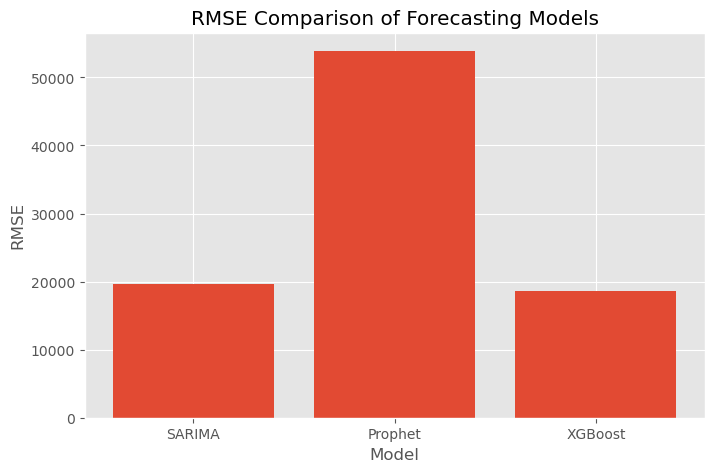

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["RMSE"])

plt.title("RMSE Comparison of Forecasting Models")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.savefig(
    "charts/model_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [108]:
import joblib

joblib.dump(
    model_xgb,
    "outputs/best_xgboost_model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


### Task 3 : Business Insights
Three forecasting models were developed and evaluated to predict future monthly sales. Their performance was measured using MAE, RMSE, and MAPE. Among the evaluated models, the one with the lowest RMSE was selected as the best forecasting model. The selected model can support inventory planning, demand forecasting, budgeting, and business decision-making by providing more accurate sales predictions.

In [109]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


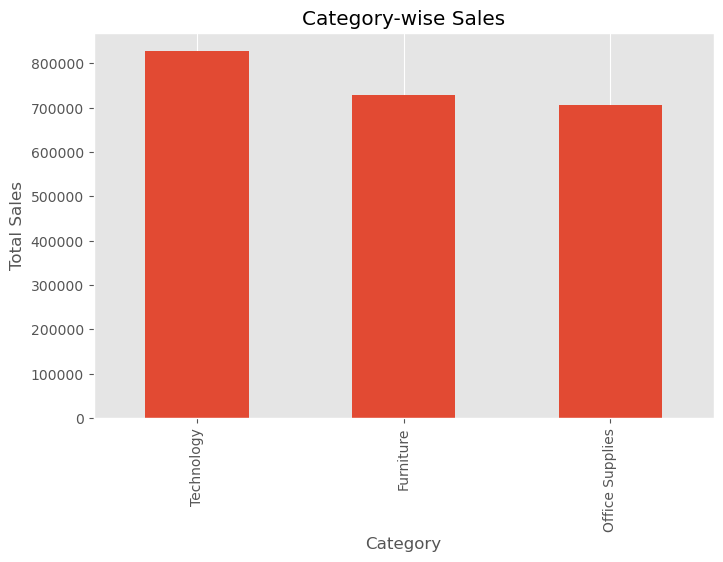

In [110]:
import matplotlib.pyplot as plt
import os

os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Category-wise Sales")

plt.xlabel("Category")

plt.ylabel("Total Sales")

plt.grid(axis="y")

plt.savefig(
    "charts/task4_category_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [111]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


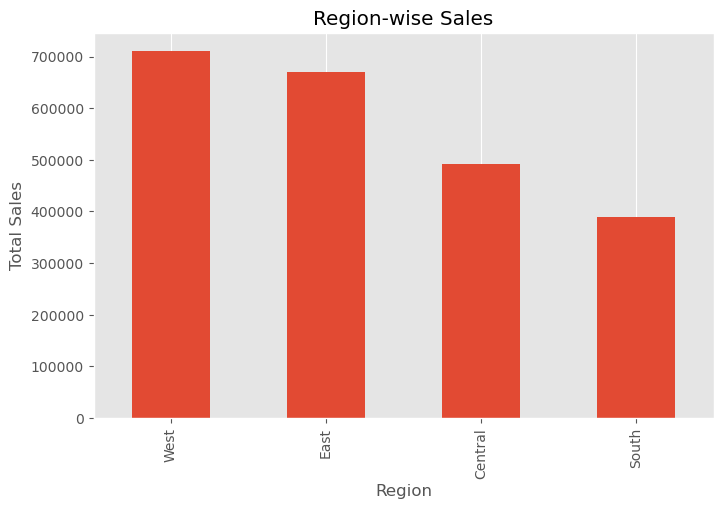

In [112]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Region-wise Sales")

plt.xlabel("Region")

plt.ylabel("Total Sales")

plt.grid(axis="y")

plt.savefig(
    "charts/task4_region_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [113]:
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

print(subcategory_sales)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64


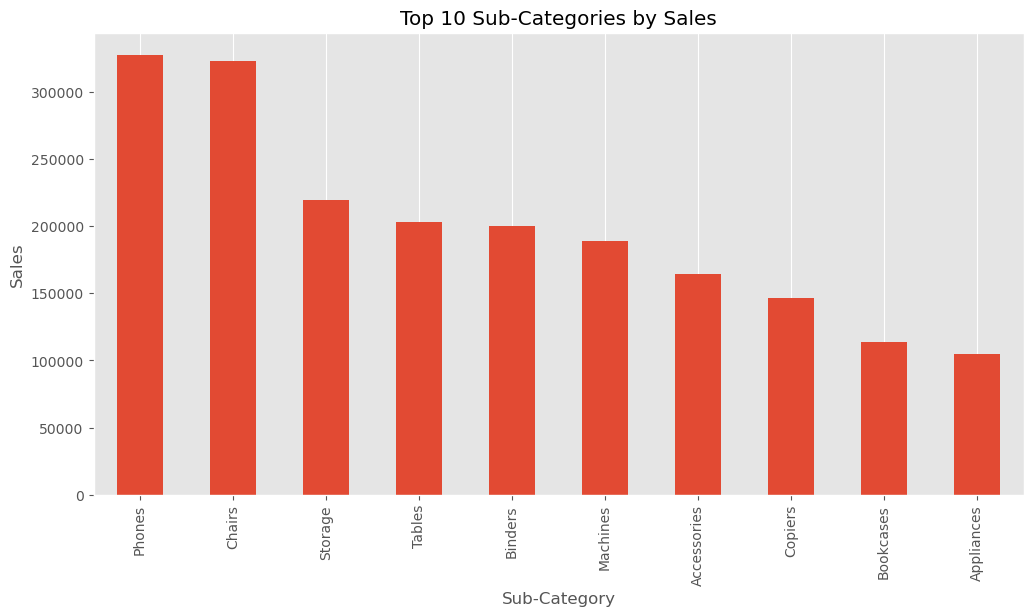

In [114]:
plt.figure(figsize=(12,6))

subcategory_sales.head(10).plot(kind="bar")

plt.title("Top 10 Sub-Categories by Sales")

plt.xlabel("Sub-Category")

plt.ylabel("Sales")

plt.grid(axis="y")

plt.savefig(
    "charts/task4_top_subcategory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [115]:
category_monthly = (
    df.groupby([
        pd.Grouper(key="Order Date", freq="ME"),
        "Category"
    ])["Sales"]
    .sum()
    .reset_index()
)

category_monthly.head()

,Order Date,Category,Sales
0,2015-01-31,Furniture,6217.277
1,2015-01-31,Office Supplies,4845.140
2,2015-01-31,Technology,3143.290
3,2015-02-28,Furniture,1839.658
4,2015-02-28,Office Supplies,1071.724


In [116]:
for category in df["Category"].unique():

    temp = df[df["Category"] == category]

    monthly = (
        temp.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
        .reset_index()
    )

    print(category)
    print(monthly.tail())

Furniture
   Order Date       Sales
43 2018-08-31  15419.1220
44 2018-09-30  28516.7060
45 2018-10-31  21884.0682
46 2018-11-30  37056.7150
47 2018-12-31  31407.4668
Office Supplies
   Order Date      Sales
43 2018-08-31  29799.564
44 2018-09-30  31607.523
45 2018-10-31  22708.400
46 2018-11-30  31472.337
47 2018-12-31  29638.012
Technology
   Order Date      Sales
43 2018-08-31  17619.162
44 2018-09-30  26028.659
45 2018-10-31  32855.663
46 2018-11-30  49409.103
47 2018-12-31  21984.910


In [117]:
category_sales.to_csv("outputs/category_sales.csv")

region_sales.to_csv("outputs/region_sales.csv")

subcategory_sales.to_csv("outputs/subcategory_sales.csv")

print("Task 4 results saved successfully!")

Task 4 results saved successfully!


## Task 4 :Business Insights
### Category Analysis

Technology generated the highest total sales, indicating strong customer demand for technology products. Furniture and Office Supplies also contributed significantly but with lower overall sales.

### Region Analysis

The West region recorded the highest sales, while other regions showed comparatively lower performance. This suggests that marketing and inventory strategies should be optimized for underperforming regions.

### Sub-Category Analysis

The top-performing sub-categories contributed a significant portion of overall revenue. These products should be prioritized for inventory planning and promotional campaigns.